# Credit card PD model and limit-management policy

**Question:** a card issuer wants to cut credit losses on its existing book without losing too much interest income. Which accounts should it restrict, and where should the cut-off sit?

**Approach:**
1. Build a probability of default (PD) model, using a logistic regression scorecard on Weight-of-Evidence (WoE) features, the standard format in retail credit.
2. Check that it ranks risk well (AUC, Gini, KS) and that its probabilities are calibrated.
3. Turn the PDs into a decision: find the cut-off that maximises expected profit, and test how sensitive that choice is to the loss assumption.

Data: UCI *Default of Credit Card Clients* (Yeh & Lien, 2009), 24,000 Taiwanese card accounts, 22% of which defaulted the following month.

In [1]:
import sys; sys.path.insert(0, "src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_curve
from scorecard import WoEEncoder, gini_ks, to_points

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
NAVY, TEAL, GREY, RED = "#1f3b5a", "#2a9d8f", "#9aa5b1", "#c8553d"

df = pd.read_csv("data/credit_default.csv")
print(df.shape); print(f"Default rate: {df['default'].mean():.1%}")

(24000, 24)
Default rate: 22.1%


## 1. Feature engineering

The raw data has six months of repayment status, bill amounts and payments. I turned these into behavioural features a credit analyst would recognise.

Sex, marital status and age are **excluded on purpose**. They are protected characteristics under the UK Equality Act, and a lender could not defend a limit decision based on them.

In [2]:
pay  = [f"PAY_{i}" for i in range(1, 7)]
bill = [f"BILL_AMT{i}" for i in range(1, 7)]
pamt = [f"PAY_AMT{i}" for i in range(1, 7)]

X = pd.DataFrame(index=df.index)
X["limit"]                = df.LIMIT_BAL
X["months_late_latest"]   = df.PAY_1.clip(lower=0)
X["worst_delinquency_6m"] = df[pay].max(axis=1).clip(lower=0)
X["n_months_late_6m"]     = (df[pay] > 0).sum(axis=1)
X["utilisation"]          = (df.BILL_AMT1 / df.LIMIT_BAL).clip(-0.5, 2)
X["avg_utilisation_6m"]   = (df[bill].mean(axis=1) / df.LIMIT_BAL).clip(-0.5, 2)
X["payment_ratio_6m"]     = (df[pamt].sum(axis=1) / df[bill].sum(axis=1).clip(lower=1)).clip(0, 2)
X["last_payment"]         = df.PAY_AMT1
X["education"]            = df.EDUCATION.where(df.EDUCATION.isin([1, 2, 3]), 4)
y = df["default"]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
print(f"Train {len(X_tr):,} | Test {len(X_te):,}")

Train 16,800 | Test 7,200


## 2. Feature selection with Information Value

Each feature is split into bins and given a WoE value (log of good-to-bad odds in that bin). Information Value (IV) sums up how well a feature separates defaulters from non-defaulters. A common rule of thumb is to keep features with IV of 0.1 or more.

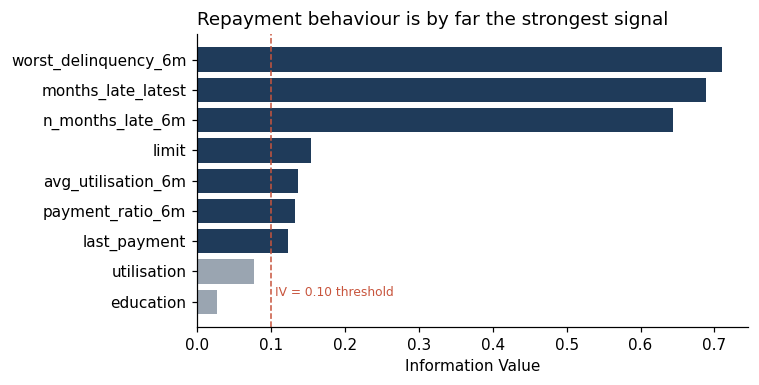

Kept: ['worst_delinquency_6m', 'months_late_latest', 'n_months_late_6m', 'limit', 'avg_utilisation_6m', 'payment_ratio_6m', 'last_payment']


In [3]:
enc_all = WoEEncoder(n_bins=6).fit(X_tr, y_tr)
iv = enc_all.iv()
keep = iv[iv >= 0.10].index.tolist()

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.barh(iv.index[::-1], iv.values[::-1], color=[NAVY if c in keep else GREY for c in iv.index[::-1]])
ax.axvline(0.10, ls="--", c=RED, lw=1); ax.text(0.105, 0.2, "IV = 0.10 threshold", color=RED, fontsize=8)
ax.set_xlabel("Information Value"); ax.set_title("Repayment behaviour is by far the strongest signal", loc="left")
plt.tight_layout(); plt.savefig("figures/01_information_value.png"); plt.show()
print("Kept:", keep)

In [4]:
# Example: WoE table for the strongest feature
enc_all.tables["worst_delinquency_6m"][["n", "bad_rate", "woe", "iv"]].round(3)

,n,bad_rate,woe,iv
bin,,,,
"(-inf, 1.0]",12105,0.128,0.658,0.256
"(1.0, 2.0]",4047,0.436,-1.001,0.301
"(2.0, inf]",648,0.616,-1.730,0.153


## 3. Fit the scorecard

In [5]:
enc = WoEEncoder(n_bins=6).fit(X_tr[keep], y_tr)
W_tr, W_te = enc.transform(X_tr[keep]), enc.transform(X_te[keep])

lr = LogisticRegression(max_iter=1000).fit(W_tr, y_tr)
pd_te = lr.predict_proba(W_te)[:, 1]

coef = pd.Series(lr.coef_[0], index=keep).round(3)
print("Coefficients (all should be negative on WoE inputs):"); print(coef)

Coefficients (all should be negative on WoE inputs):
worst_delinquency_6m   -0.364
months_late_latest     -0.586
n_months_late_6m       -0.297
limit                  -0.159
avg_utilisation_6m     -0.394
payment_ratio_6m       -0.205
last_payment           -0.754
dtype: float64


## 4. Validation

A benchmark gradient boosting model is fitted on the same features to show how much accuracy the simpler, explainable scorecard gives up.

In [6]:
gb = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, random_state=42).fit(X_tr[keep], y_tr)
pd_gb = gb.predict_proba(X_te[keep])[:, 1]
pd_tr = lr.predict_proba(W_tr)[:, 1]

results = pd.DataFrame({
    "Scorecard (train)": gini_ks(y_tr, pd_tr),
    "Scorecard (test)":  gini_ks(y_te, pd_te),
    "Gradient boosting (test)": gini_ks(y_te, pd_gb),
}).T.round(3)
results

,AUC,Gini,KS
Scorecard (train),0.766,0.531,0.409
Scorecard (test),0.770,0.540,0.422
Gradient boosting (test),0.781,0.562,0.442


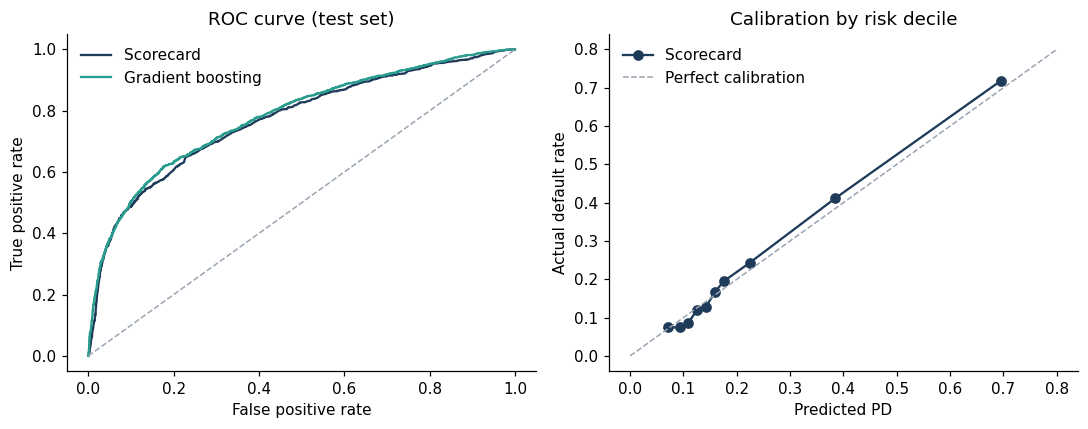

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for p, lab, col in [(pd_te, "Scorecard", NAVY), (pd_gb, "Gradient boosting", TEAL)]:
    fpr, tpr, _ = roc_curve(y_te, p); axes[0].plot(fpr, tpr, c=col, label=lab)
axes[0].plot([0, 1], [0, 1], c=GREY, ls="--", lw=1)
axes[0].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC curve (test set)"); axes[0].legend(frameon=False)

cal = pd.DataFrame({"pd": pd_te, "y": y_te.values})
cal["decile"] = pd.qcut(cal.pd, 10, labels=False, duplicates="drop")
g = cal.groupby("decile").agg(predicted=("pd", "mean"), actual=("y", "mean"))
axes[1].plot(g.predicted, g.actual, "o-", c=NAVY, label="Scorecard")
axes[1].plot([0, 0.8], [0, 0.8], c=GREY, ls="--", lw=1, label="Perfect calibration")
axes[1].set(xlabel="Predicted PD", ylabel="Actual default rate", title="Calibration by risk decile"); axes[1].legend(frameon=False)
plt.tight_layout(); plt.savefig("figures/02_roc_calibration.png"); plt.show()

## 5. From PD to a credit score

The probabilities are rescaled to points in the usual way: 600 points means odds of 50:1, and every extra 20 points doubles the odds of the account staying good.

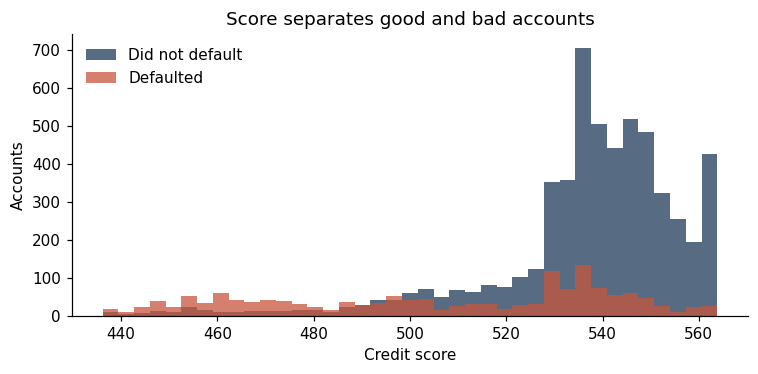

In [8]:
score_te = to_points(pd_te)
fig, ax = plt.subplots(figsize=(7, 3.5))
bins = np.linspace(score_te.min(), score_te.max(), 40)
ax.hist(score_te[y_te.values == 0], bins=bins, alpha=0.75, color=NAVY, label="Did not default")
ax.hist(score_te[y_te.values == 1], bins=bins, alpha=0.75, color=RED, label="Defaulted")
ax.set(xlabel="Credit score", ylabel="Accounts", title="Score separates good and bad accounts")
ax.legend(frameon=False); plt.tight_layout(); plt.savefig("figures/03_score_distribution.png"); plt.show()

### Scorecard points table and reason codes

A scorecard is usually handed to the business as a points table: each feature bin earns a fixed number of points, and the points add up to the score. The same table gives **reason codes**, the features that pulled a customer's score down the most. Lenders need these to explain a decision to a customer.

In [9]:
factor = 20 / np.log(2)
offset = 600 - factor * np.log(50)
b0, n = lr.intercept_[0], len(keep)

rows = []
for f, b in zip(keep, lr.coef_[0]):
    t = enc.tables[f]
    for bin_, w in t["woe"].items():
        rows.append({"feature": f, "bin": str(bin_),
                     "points": round(-factor * b * w + (offset - factor * b0) / n)})
points = pd.DataFrame(rows)
points.to_csv("figures/scorecard_points.csv", index=False)
points[points.feature.isin(["months_late_latest", "payment_ratio_6m"])]

,feature,bin,points
3,months_late_latest,"(-inf, 1.0]",81
4,months_late_latest,"(1.0, inf]",40
20,payment_ratio_6m,"(-inf, 0.037]",72
21,payment_ratio_6m,"(0.037, 0.0477]",74
22,payment_ratio_6m,"(0.0477, 0.0876]",73
23,payment_ratio_6m,"(0.0876, 0.335]",76
24,payment_ratio_6m,"(0.335, 0.89]",77
25,payment_ratio_6m,"(0.89, inf]",77


In [10]:
def reason_codes(i, top=3):
    # Features where this account lost the most points against the best bin for that feature
    row = W_te.iloc[i]
    lost = {}
    for f, b in zip(keep, lr.coef_[0]):
        best_woe = enc.tables[f]["woe"].max()
        lost[f] = -factor * b * (best_woe - row[f])
    return pd.Series(lost).sort_values(ascending=False).head(top).round(0)

riskiest = int(np.argmax(pd_te))
print(f"Example account: PD {pd_te[riskiest]:.0%}, score {score_te[riskiest]:.0f}")
print("Top reasons (points lost versus best possible bin):")
print(reason_codes(riskiest))

Example account: PD 85%, score 436
Top reasons (points lost versus best possible bin):
months_late_latest      41.0
worst_delinquency_6m    25.0
last_payment            21.0
dtype: float64


## 6. The business decision: where to set the cut-off

**Setting.** The bank reviews its existing card book. Accounts above a PD cut-off have their limits frozen. That avoids most of the loss if they default, but the bank also gives up the income they would have earned.

**Assumptions** (simple and stated, so they can be challenged):
- Exposure at default (EAD) is the latest statement balance.
- A good account earns net income of about 10% of balance a year (interest and fees minus funding cost), and a typical customer stays about three years. Keeping a good customer is therefore worth about **30% of balance**.
- Loss given default (LGD) is 75% of balance, typical for unsecured card debt.

With these, restricting an account only pays off when its PD is above **value / (value + LGD) = 30 / 105, or about 29%**. The analysis below checks that on the test set.

In [11]:
REV, LGD = 0.30, 0.75   # lifetime value of a good account, loss given default
book = pd.DataFrame({"pd": pd_te, "y": y_te.values,
                     "ead": df.loc[X_te.index, "BILL_AMT1"].clip(lower=0).values})
book["value_if_kept"] = np.where(book.y == 1, -LGD * book.ead, REV * book.ead)

def policy(cutoff, b=book):
    restricted = b.pd >= cutoff
    return {"cutoff": cutoff,
            "share_restricted": restricted.mean(),
            "profit": b.loc[~restricted, "value_if_kept"].sum(),
            "defaults_caught": b.loc[restricted, "y"].sum() / b.y.sum()}

grid = pd.DataFrame([policy(c) for c in np.arange(0.02, 0.91, 0.01)])
baseline = book.value_if_kept.sum()   # restrict nobody
best = grid.loc[grid.profit.idxmax()]
print(f"Profit if nobody is restricted: NT${baseline/1e6:,.1f}m")
print(f"Best cut-off: PD {best.cutoff:.0%} -> profit NT${best.profit/1e6:,.1f}m "
      f"(restrict {best.share_restricted:.0%} of accounts, catch {best.defaults_caught:.0%} of defaults)")

Profit if nobody is restricted: NT$29.5m
Best cut-off: PD 32% -> profit NT$53.8m (restrict 18% of accounts, catch 48% of defaults)


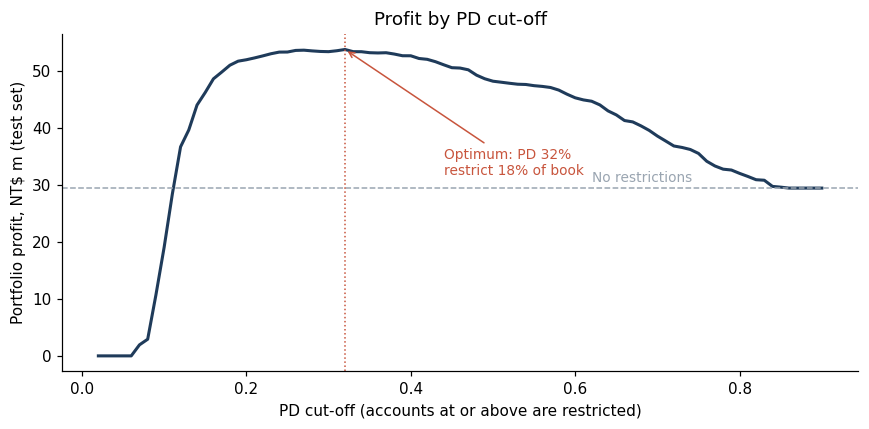

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(grid.cutoff, grid.profit / 1e6, c=NAVY, lw=2)
ax.axhline(baseline / 1e6, c=GREY, ls="--", lw=1); ax.text(0.62, baseline/1e6 + 1, "No restrictions", color=GREY, fontsize=9)
ax.axvline(best.cutoff, c=RED, ls=":", lw=1)
ax.annotate(f"Optimum: PD {best.cutoff:.0%}\nrestrict {best.share_restricted:.0%} of book",
            (best.cutoff, best.profit / 1e6), xytext=(best.cutoff + 0.12, best.profit / 1e6 - 22),
            arrowprops=dict(arrowstyle="->", color=RED), color=RED, fontsize=9)
ax.set(xlabel="PD cut-off (accounts at or above are restricted)", ylabel="Portfolio profit, NT$ m (test set)",
       title="Profit by PD cut-off")
plt.tight_layout(); plt.savefig("figures/04_profit_by_cutoff.png"); plt.show()

### Sensitivity: how much does the answer depend on LGD?

LGD is the least certain assumption, so the optimisation is re-run for a range of values.

In [13]:
rows = []
for lgd in [0.50, 0.65, 0.75, 0.90]:
    b = book.copy(); b["value_if_kept"] = np.where(b.y == 1, -lgd * b.ead, REV * b.ead)
    gg = pd.DataFrame([policy(c, b) for c in np.arange(0.02, 0.91, 0.01)])
    bb = gg.loc[gg.profit.idxmax()]
    rows.append({"LGD": f"{lgd:.0%}", "break-even PD": f"{REV/(REV+lgd):.1%}",
                 "best cut-off": f"{bb.cutoff:.0%}", "share restricted": f"{bb.share_restricted:.0%}",
                 "profit uplift vs no action (NT$m)": round((bb.profit - b.value_if_kept.sum()) / 1e6, 1)})
pd.DataFrame(rows)

,LGD,break-even PD,best cut-off,share restricted,profit uplift vs no action (NT$m)
0,50%,37.5%,37%,16%,13.6
1,65%,31.6%,32%,18%,20.0
2,75%,28.6%,32%,18%,24.3
3,90%,25.0%,26%,22%,31.0


### A three-band policy the business can run

A single cut-off is hard to operate, so the book is split into bands with a clear action for each.

In [14]:
bands = pd.cut(book.pd, [0, 0.10, 0.30, 1], labels=["Low (PD < 10%)", "Medium (10-30%)", "High (PD >= 30%)"])
tbl = book.groupby(bands, observed=False).agg(accounts=("y", "size"), default_rate=("y", "mean"),
                                               defaults=("y", "sum"), balance=("ead", "sum"))
tbl["share_of_book"] = tbl.accounts / tbl.accounts.sum()
tbl["share_of_defaults"] = tbl.defaults / tbl.defaults.sum()
tbl["action"] = ["Keep; eligible for limit increase", "Monitor; no limit increases", "Freeze or reduce limit"]
tbl[["share_of_book", "default_rate", "share_of_defaults", "action"]].style.format(
    {"share_of_book": "{:.0%}", "default_rate": "{:.0%}", "share_of_defaults": "{:.0%}"})

,share_of_book,default_rate,share_of_defaults,action
pd,,,,
Low (PD < 10%),18%,7%,6%,Keep; eligible for limit increase
Medium (10-30%),62%,16%,44%,Monitor; no limit increases
High (PD >= 30%),19%,57%,50%,Freeze or reduce limit


## 7. Expected loss and a simple IFRS 9 view

The same PDs feed provisioning. For each account, **expected loss = PD × LGD × EAD**. Two checks:

1. **Backtest:** does predicted loss match the loss that actually happened in the test set, overall and by risk band?
2. **Staging:** IFRS 9 moves accounts to Stage 2 when credit risk has risen significantly (30+ days past due is the standard backstop) and to Stage 3 when they are credit-impaired (90+ days past due). Here that is mapped from the latest repayment status.

This is a simplified view: the PDs are next-month, so the numbers are a one-month expected loss, not a 12-month or lifetime ECL.

In [15]:
book["expected_loss"] = book.pd * LGD * book.ead
book["actual_loss"] = book.y * LGD * book.ead
book["band"] = bands

bt = book.groupby("band", observed=False)[["expected_loss", "actual_loss", "ead"]].sum()
bt.loc["Total"] = bt.sum()
bt["EL % of balance"] = bt.expected_loss / bt.ead
bt["predicted / actual"] = bt.expected_loss / bt.actual_loss
bt[["expected_loss", "actual_loss"]] = (bt[["expected_loss", "actual_loss"]] / 1e6).round(1)
bt.rename(columns={"expected_loss": "expected loss (NT$m)", "actual_loss": "actual loss (NT$m)"})[
    ["expected loss (NT$m)", "actual loss (NT$m)", "EL % of balance", "predicted / actual"]].style.format(
    {"expected loss (NT$m)": "{:.1f}", "actual loss (NT$m)": "{:.1f}", "EL % of balance": "{:.1%}", "predicted / actual": "{:.2f}"})

,expected loss (NT$m),actual loss (NT$m),EL % of balance,predicted / actual
band,,,,
Low (PD < 10%),5.2,3.5,6.5%,1.49
Medium (10-30%),22.5,21.6,10.4%,1.04
High (PD >= 30%),31.0,32.7,42.6%,0.95
Total,58.7,57.9,15.9%,1.01


In [16]:
status = df.loc[X_te.index, "PAY_1"].values
book["stage"] = np.select([status >= 3, status >= 1], ["Stage 3 (90+ dpd)", "Stage 2 (30+ dpd)"], "Stage 1 (performing)")
st = book.groupby("stage").agg(accounts=("y", "size"), avg_pd=("pd", "mean"),
                               default_rate=("y", "mean"), expected_loss=("expected_loss", "sum"))
st["share_of_book"] = st.accounts / st.accounts.sum()
st["share_of_EL"] = st.expected_loss / st.expected_loss.sum()
st[["share_of_book", "avg_pd", "default_rate", "share_of_EL"]].style.format("{:.0%}")

,share_of_book,avg_pd,default_rate,share_of_EL
stage,,,,
Stage 1 (performing),78%,15%,14%,49%
Stage 2 (30+ dpd),20%,44%,49%,44%
Stage 3 (90+ dpd),2%,81%,67%,7%


## 8. Findings

The numbers in the README are generated by this notebook.

- **Past repayment behaviour drives risk.** The worst delinquency in the last six months and the latest payment status carry most of the predictive power. Demographics add almost nothing, which makes the model easier to defend.
- **The simple scorecard is close to machine learning.** Gradient boosting improves Gini by only a few points. For a regulated lending decision, most banks would accept that gap in exchange for a model they can explain to customers, auditors and the regulator.
- **The model is calibrated.** Predicted PDs track actual default rates across deciles, so they can be used directly in pricing and in provisioning (expected loss = PD × LGD × EAD).
- **Predicted loss matches actual loss at portfolio level** (within about 1%), so the PDs are usable for provisioning as well as ranking. The model overstates loss in the lowest-risk band and for Stage 3 accounts, so it errs on the conservative side where it is off.
- **Restricting a targeted high-risk slice of the book pays off.** The profit curve peaks near the theoretical break-even PD. Going stricter than that throws away good customers faster than it avoids losses. The curve is also flat between roughly 20% and 45%, so the bank has room to pick a cut-off that suits its risk appetite without giving up much profit.

## 9. Limitations and next steps
- The target is default in the *next month*. A Basel or IFRS 9 PD uses a 12-month window, so these PDs would need rescaling for capital or provisioning use.
- This data comes from Taiwan in 2005, during a card-debt crisis, so the 22% default rate is far above a normal UK book. The policy logic carries over; the specific cut-off would need re-fitting on current data.
- The customer value and LGD figures are assumptions, not bank data. The sensitivity table shows the recommendation holds across a sensible range.
- The test set is from the same period as training. A real validation would add an out-of-time sample and population stability (PSI) monitoring.
- Freezing a limit does not remove all loss (customers may already be drawn). A fuller version would model partial loss avoidance.